In [27]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [28]:
normal_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

minority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.ToTensor(),
])

In [29]:
data_path = "/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers"

full_dataset = datasets.ImageFolder(root=data_path)
class_names = full_dataset.classes
num_classes = len(class_names)

print(class_names)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


In [30]:
target_counts = {
    "daisy": 100,
    "dandelion": 500,
    "rose": 200,
    "sunflower": 50,
    "tulip": 150
}

indices_per_class = {i: [] for i in range(num_classes)}

for idx, (_, label) in enumerate(full_dataset):
    indices_per_class[label].append(idx)

imbalanced_indices = []

for class_idx, class_name in enumerate(class_names):
    class_indices = indices_per_class[class_idx]
    random.shuffle(class_indices)
    imbalanced_indices.extend(class_indices[:target_counts[class_name]])

imbalanced_dataset = Subset(full_dataset, imbalanced_indices)

print("Total samples:", len(imbalanced_dataset))

Total samples: 1000


In [31]:
labels = [imbalanced_dataset[i][1] for i in range(len(imbalanced_dataset))]

train_idx, test_idx = train_test_split(
    range(len(imbalanced_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(imbalanced_dataset, train_idx)
test_subset  = Subset(imbalanced_dataset, test_idx)

In [32]:
class FlowerDataset(torch.utils.data.Dataset):
    def __init__(self, subset, train=True):
        self.subset = subset
        self.train = train
        self.minority_classes = ["sunflower", "daisy", "tulip"]

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        class_name = class_names[label]

        if self.train and class_name in self.minority_classes:
            image = minority_transform(image)
        else:
            image = normal_transform(image)

        return image, label

In [33]:
train_dataset = FlowerDataset(train_subset, train=True)
test_dataset  = FlowerDataset(test_subset, train=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [34]:
class_counts = Counter(labels)

total_samples = sum(class_counts.values())
class_weights = []

for i in range(num_classes):
    class_weights.append(total_samples / class_counts[i])

class_weights = torch.tensor(class_weights).float().to(device)
print("Class Weights:", class_weights)

Class Weights: tensor([10.0000,  2.0000,  5.0000, 20.0000,  6.6667], device='cuda:0')


In [35]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)

        at = self.alpha.gather(0, targets)
        loss = at * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2)

In [36]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [37]:
def train_model(model, epochs=5):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss/len(train_loader):.4f} "
              f"Accuracy: {100*correct/total:.2f}%")

In [38]:
def evaluate_model(model):
    model.eval()
    correct = 0
    total = 0
    top3_correct = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

            _, top3 = outputs.topk(3, dim=1)
            top3_correct += top3.eq(labels.view(-1,1)).sum().item()

            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("Overall Accuracy:", 100*correct/total)
    print("Top-3 Accuracy:", 100*top3_correct/total)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names,
                                digits=4))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Epoch [1/5] Loss: 72.0611 Accuracy: 17.88%
Epoch [2/5] Loss: 5.4270 Accuracy: 18.88%
Epoch [3/5] Loss: 5.2611 Accuracy: 22.25%
Epoch [4/5] Loss: 5.8695 Accuracy: 12.75%
Epoch [5/5] Loss: 5.0579 Accuracy: 14.00%
Overall Accuracy: 18.0
Top-3 Accuracy: 58.0

Classification Report:
              precision    recall  f1-score   support

       daisy     0.2031    0.6500    0.3095        20
   dandelion     0.0000    0.0000    0.0000       100
        rose     0.0000    0.0000    0.0000        40
   sunflower     0.0000    0.0000    0.0000        10
       tulip     0.1855    0.7667    0.2987        30

    accuracy                         0.1800       200
   macro avg     0.0777    0.2833    0.1216       200
weighted avg     0.0481    0.1800    0.0758       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


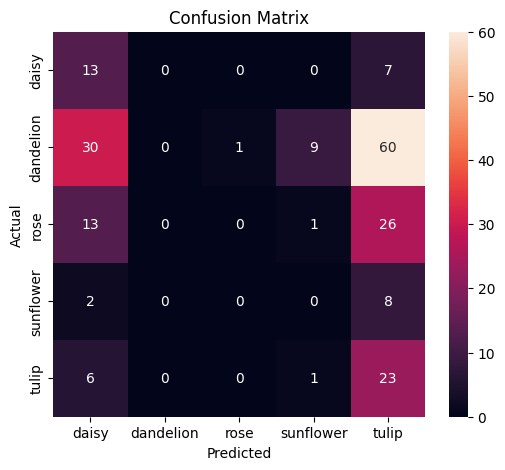

In [39]:
custom_model = CustomCNN(num_classes)

train_model(custom_model, epochs=5)
evaluate_model(custom_model)

In [40]:
from torchvision import models

resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(2048, num_classes)
resnet_model = resnet_model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 123MB/s] 


Epoch [1/5] Loss: 1.9974 Accuracy: 72.00%
Epoch [2/5] Loss: 0.4212 Accuracy: 95.00%
Epoch [3/5] Loss: 0.2637 Accuracy: 95.38%
Epoch [4/5] Loss: 0.1570 Accuracy: 96.62%
Epoch [5/5] Loss: 0.1204 Accuracy: 97.62%
Overall Accuracy: 88.5
Top-3 Accuracy: 98.0

Classification Report:
              precision    recall  f1-score   support

       daisy     0.9474    0.9000    0.9231        20
   dandelion     0.9515    0.9800    0.9655       100
        rose     0.7273    0.8000    0.7619        40
   sunflower     1.0000    0.7000    0.8235        10
       tulip     0.8148    0.7333    0.7719        30

    accuracy                         0.8850       200
   macro avg     0.8882    0.8227    0.8492       200
weighted avg     0.8881    0.8850    0.8844       200



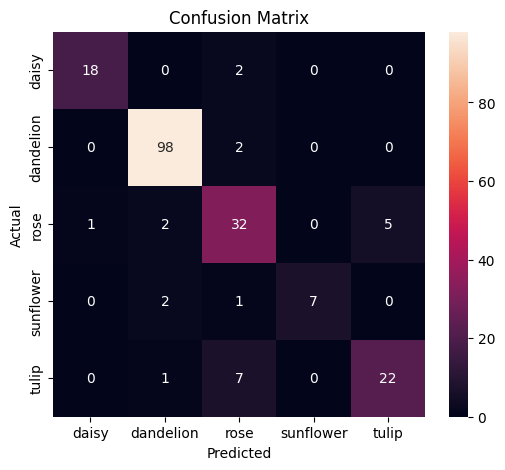

In [ ]:
train_model(resnet_model, epochs=5)
evaluate_model(resnet_model)

In [47]:
efficient_model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

for param in efficient_model.parameters():
    param.requires_grad = False

efficient_model.classifier[1] = nn.Linear(1280, num_classes)
efficient_model = efficient_model.to(device)

Epoch [1/5] Loss: 2.6432 Accuracy: 68.00%
Epoch [2/5] Loss: 1.2373 Accuracy: 88.00%
Epoch [3/5] Loss: 1.1717 Accuracy: 86.75%
Epoch [4/5] Loss: 1.4542 Accuracy: 87.62%
Epoch [5/5] Loss: 1.6558 Accuracy: 86.88%
Overall Accuracy: 80.5
Top-3 Accuracy: 96.5

Classification Report:
              precision    recall  f1-score   support

       daisy     0.6154    0.8000    0.6957        20
   dandelion     0.9647    0.8200    0.8865       100
        rose     0.6981    0.9250    0.7957        40
   sunflower     0.6000    0.6000    0.6000        10
       tulip     0.7692    0.6667    0.7143        30

    accuracy                         0.8050       200
   macro avg     0.7295    0.7623    0.7384       200
weighted avg     0.8289    0.8050    0.8091       200



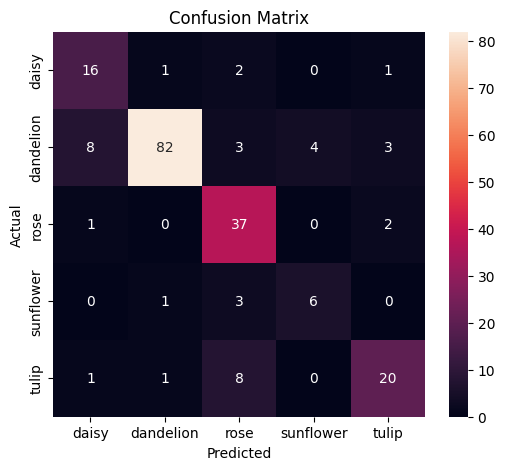

In [ ]:
train_model(efficient_model, epochs=5)
evaluate_model(efficient_model)

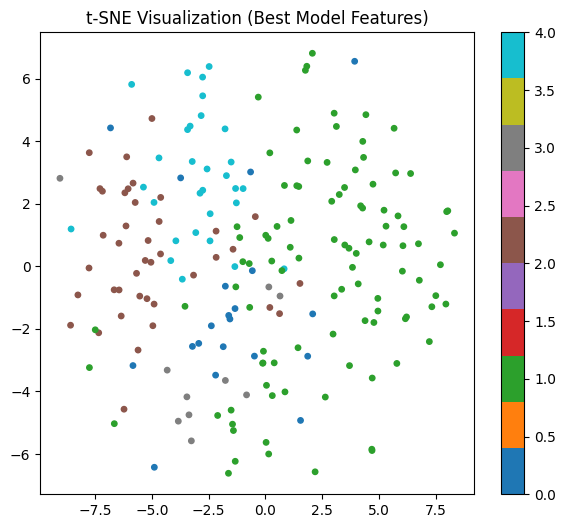

In [ ]:
best_model = efficient_model
best_model.eval()

def extract_features(model, loader):
    features_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            # Extract backbone features
            x = model.features(images)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)

            features_list.append(x.cpu())
            labels_list.extend(labels.numpy())

    features = torch.cat(features_list, dim=0)
    return features.numpy(), np.array(labels_list)

features, labels = extract_features(best_model, test_loader)

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(features)

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    features_2d[:,0],
    features_2d[:,1],
    c=labels,
    cmap="tab10",
    s=15
)

plt.title("t-SNE Visualization (Best Model Features)")
plt.colorbar(scatter)
plt.show()

In [51]:
# Transfer Learning
intel_path = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"

intel_dataset = datasets.ImageFolder(root=intel_path)
intel_classes = intel_dataset.classes
intel_num_classes = len(intel_classes)

print(intel_classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [52]:
target_intel_counts = {
    "buildings": 1500,
    "forest": 1500,
    "glacier": 400,
    "mountain": 1500,
    "sea": 1500,
    "street": 400
}

indices_per_class = {i: [] for i in range(intel_num_classes)}

for idx, (_, label) in enumerate(intel_dataset):
    indices_per_class[label].append(idx)

imbalanced_intel_indices = []

for class_idx, class_name in enumerate(intel_classes):
    class_indices = indices_per_class[class_idx]
    random.shuffle(class_indices)
    imbalanced_intel_indices.extend(
        class_indices[:target_intel_counts[class_name]]
    )

intel_imbalanced = Subset(intel_dataset, imbalanced_intel_indices)

In [53]:
class IntelDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        image = normal_transform(image)
        return image, label

In [54]:
intel_loader = DataLoader(
    IntelDataset(intel_imbalanced),
    batch_size=32,
    shuffle=True
)

In [55]:
transfer_model = best_model

transfer_model.classifier[1] = nn.Linear(1280, intel_num_classes)
transfer_model = transfer_model.to(device)

In [56]:
def train_transfer(model, loader, epochs=5):
    optimizer = optim.SGD(
        model.classifier[1].parameters(),
        lr=0.01,
        momentum=0.9
    )

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = nn.CrossEntropyLoss()(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        print(f"Epoch {epoch+1}: Accuracy {100*correct/total:.2f}%")

In [57]:
train_transfer(transfer_model, intel_loader, epochs=5)

Epoch 1: Accuracy 83.72%
Epoch 2: Accuracy 89.59%
Epoch 3: Accuracy 90.16%
Epoch 4: Accuracy 90.99%
Epoch 5: Accuracy 90.66%
